# N-Gram Language Modeling with Unknown Words

| Assignment field | Details |
|---|---|
| **Group Number** | 90 |
| **Problem Statement** | 9 - N-gram Language Modeling with Unknown Words |
| **Dataset** | NLTK Gutenberg Corpus |
| **Student Name(s)** |  |
| **Course/Subject** |  |

## 1. Introduction

A **language model** assigns probabilities to sequences of words and can use them to predict likely words. An **N-gram** is a sequence of *N* consecutive tokens. A **trigram** model uses the previous two words to estimate the next word:

$$P(w_i \mid w_{i-2}, w_{i-1})$$

Words absent from the training vocabulary are a problem because the model has no counts for them. We use the special token `<UNK>` (unknown) to group rare training words and represent unseen test words. This gives the model a learned way to handle unfamiliar vocabulary.

## 2. Objective

This assignment will:

- build a trigram language model;
- analyze rare words and replace training words occurring fewer than 3 times with `<UNK>`;
- perform next-word and missing-word prediction;
- compare models with and without `<UNK>`;
- compare no smoothing with Laplace (add-one) smoothing; and
- evaluate accuracy, OOV rate, coverage, and perplexity.

## 3. Import libraries and reproducible setup

The setup checks for NLTK resources and downloads them only when absent. The fixed seed makes any sampling deterministic.

In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import math
import random
import re
import sys

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
from IPython.display import display

SEED = 90
random.seed(SEED)
np.random.seed(SEED)
pd.set_option("display.max_colwidth", 90)

# Keep downloaded NLTK resources in an ignored local cache when possible.
NLTK_DATA_DIR = Path.cwd() / ".nltk_data"
NLTK_DATA_DIR.mkdir(exist_ok=True)
if str(NLTK_DATA_DIR) not in nltk.data.path:
    nltk.data.path.insert(0, str(NLTK_DATA_DIR))

required_resources = {
    "gutenberg": "corpora/gutenberg",
    "punkt": "tokenizers/punkt",
    "punkt_tab": "tokenizers/punkt_tab",
}
for package, resource_path in required_resources.items():
    try:
        nltk.data.find(resource_path)
    except LookupError:
        nltk.download(package, download_dir=str(NLTK_DATA_DIR), quiet=True, raise_on_error=True)

from nltk.corpus import gutenberg

print(f"Python: {sys.version.split()[0]}")
print(f"NLTK: {nltk.__version__}")
print(f"Random seed: {SEED}")

Python: 3.14.6
NLTK: 3.10.3
Random seed: 90


## 4. Load and inspect the NLTK Gutenberg Corpus

We first list every available file, then select one sufficiently large book. `austen-emma.txt` is suitable because it contains many sentences and repeated everyday vocabulary, while still containing rare words for the `<UNK>` experiment.

In [2]:
available_books = gutenberg.fileids()
selected_book = "austen-emma.txt"

books_df = pd.DataFrame({"Available Gutenberg file": available_books})
display(books_df)
print(f"Number of books available: {len(available_books)}")
print(f"Selected book: {selected_book}")

,Available Gutenberg file
0,austen-emma.txt
1,austen-persuasion.txt
2,austen-sense.txt
3,bible-kjv.txt
4,blake-poems.txt
5,bryant-stories.txt
6,burgess-busterbrown.txt
7,carroll-alice.txt
8,chesterton-ball.txt
9,chesterton-brown.txt


Number of books available: 18
Selected book: austen-emma.txt


In [3]:
raw_text = gutenberg.raw(selected_book)
raw_sentences = list(gutenberg.sents(selected_book))
raw_tokens = list(gutenberg.words(selected_book))

corpus_stats_df = pd.DataFrame({
    "Statistic": ["Selected book", "Raw characters", "Raw sentences", "Tokens before preprocessing"],
    "Value": [selected_book, len(raw_text), len(raw_sentences), len(raw_tokens)],
})
display(corpus_stats_df)

,Statistic,Value
0,Selected book,austen-emma.txt
1,Raw characters,887071
2,Raw sentences,7752
3,Tokens before preprocessing,192427


## 5. Text preprocessing

Preprocessing decisions are explicit:

1. NLTK's Gutenberg sentence boundaries are retained.
2. Tokens are lowercased so `The` and `the` share counts.
3. Alphabetic words and internal apostrophes are kept; standalone punctuation and numbers are removed.
4. Two `<START>` tokens and one `<END>` token are added during trigram counting. Two starts are required because a trigram needs two preceding tokens.
5. `<UNK>` is **not** added yet; it is learned from training frequencies later.

In [4]:
WORD_PATTERN = re.compile(r"^[A-Za-z]+(?:'[A-Za-z]+)?$")

def preprocess_sentence(tokens):
    # Lowercase and retain word-like tokens while preserving the sentence as a list.
    return [token.lower() for token in tokens if WORD_PATTERN.fullmatch(token)]

processed_sentences = [preprocess_sentence(sentence) for sentence in raw_sentences]
processed_sentences = [sentence for sentence in processed_sentences if sentence]

example_rows = []
for original, processed in zip(raw_sentences[:5], processed_sentences[:5]):
    example_rows.append({
        "Original sentence": " ".join(original[:30]),
        "After preprocessing": " ".join(processed[:30]),
    })
display(pd.DataFrame(example_rows))

,Original sentence,After preprocessing
0,[ Emma by Jane Austen 1816 ],emma by jane austen
1,VOLUME I,volume i
2,CHAPTER I,chapter i
3,"Emma Woodhouse , handsome , clever , and rich , with a comfortable home and happy disp...",emma woodhouse handsome clever and rich with a comfortable home and happy disposition ...
4,"She was the youngest of the two daughters of a most affectionate , indulgent father ; ...",she was the youngest of the two daughters of a most affectionate indulgent father and ...


## 6. Train/test data preparation

The corpus is split at sentence boundaries: the first 80% of sentences are training data and the remaining 20% are test data. This chronological, deterministic split prevents test sentences from influencing training counts or the `<UNK>` vocabulary.

In [5]:
split_index = int(0.80 * len(processed_sentences))
train_sentences = processed_sentences[:split_index]
test_sentences = processed_sentences[split_index:]

split_df = pd.DataFrame({
    "Split": ["Training", "Testing", "Total"],
    "Sentences": [len(train_sentences), len(test_sentences), len(processed_sentences)],
    "Percentage": [100 * len(train_sentences) / len(processed_sentences),
                   100 * len(test_sentences) / len(processed_sentences), 100.0],
})
display(split_df.style.format({"Percentage": "{:.1f}%"}))

,Split,Sentences,Percentage
0,Training,6170,80.0%
1,Testing,1543,20.0%
2,Total,7713,100.0%


## 7. Exploratory Data Analysis

EDA is reported on the training split because training frequencies determine the vocabulary and rare-word rule. This also avoids looking at test data when designing `<UNK>`.

In [6]:
train_tokens = [word for sentence in train_sentences for word in sentence]
test_tokens = [word for sentence in test_sentences for word in sentence]
train_frequency = Counter(train_tokens)

words_once = sum(count == 1 for count in train_frequency.values())
words_twice = sum(count == 2 for count in train_frequency.values())
rare_types = sum(count < 3 for count in train_frequency.values())
rare_token_count = sum(count for count in train_frequency.values() if count < 3)

frequency_stats_df = pd.DataFrame({
    "Statistic": ["Total training tokens", "Unique training words", "Words occurring once",
                  "Words occurring twice", "Word types occurring < 3 times",
                  "Rare-token occurrences", "Rare types as % of vocabulary"],
    "Value": [len(train_tokens), len(train_frequency), words_once, words_twice,
              rare_types, rare_token_count, 100 * rare_types / len(train_frequency)],
})
display(frequency_stats_df.style.format({"Value": lambda x: f"{x:,.2f}" if isinstance(x, float) else f"{x:,}"}))
display(pd.DataFrame(train_frequency.most_common(20), columns=["Word", "Frequency"]))

,Statistic,Value
0,Total training tokens,"124,702.00"
1,Unique training words,"6,377.00"
2,Words occurring once,"2,530.00"
3,Words occurring twice,978.00
4,Word types occurring < 3 times,"3,508.00"
5,Rare-token occurrences,"4,486.00"
6,Rare types as % of vocabulary,55.01


,Word,Frequency
0,the,4011
1,to,3975
2,and,3881
3,of,3331
4,i,2475
5,a,2474
6,it,1920
7,was,1804
8,her,1758
9,not,1671


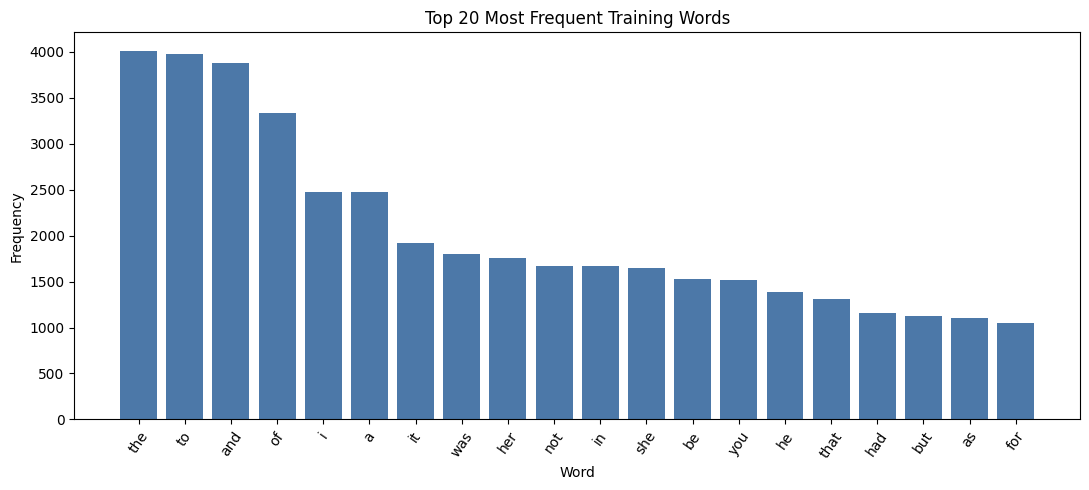

Interpretation: Function words dominate the corpus, so they are likely predictions in many common contexts.


In [7]:
top_words = pd.DataFrame(train_frequency.most_common(20), columns=["Word", "Frequency"])
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(top_words["Word"], top_words["Frequency"], color="#4C78A8")
ax.set_title("Top 20 Most Frequent Training Words")
ax.set_xlabel("Word")
ax.set_ylabel("Frequency")
ax.tick_params(axis="x", rotation=55)
plt.tight_layout()
plt.show()
print("Interpretation: Function words dominate the corpus, so they are likely predictions in many common contexts.")

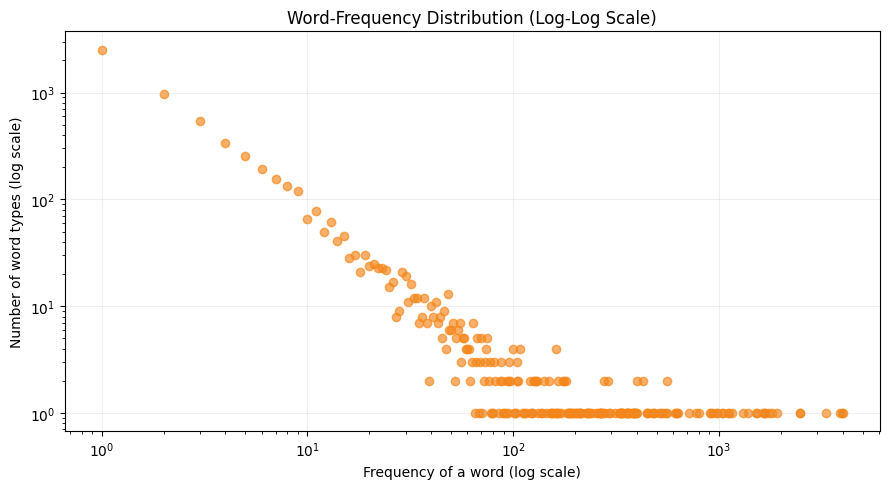

Interpretation: Most word types occur only a few times, while a small number occur very often.


In [8]:
frequency_of_frequencies = Counter(train_frequency.values())
freq_df = pd.DataFrame(sorted(frequency_of_frequencies.items()), columns=["Word frequency", "Number of word types"])

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(freq_df["Word frequency"], freq_df["Number of word types"], alpha=0.65, color="#F58518")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Word-Frequency Distribution (Log-Log Scale)")
ax.set_xlabel("Frequency of a word (log scale)")
ax.set_ylabel("Number of word types (log scale)")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()
print("Interpretation: Most word types occur only a few times, while a small number occur very often.")

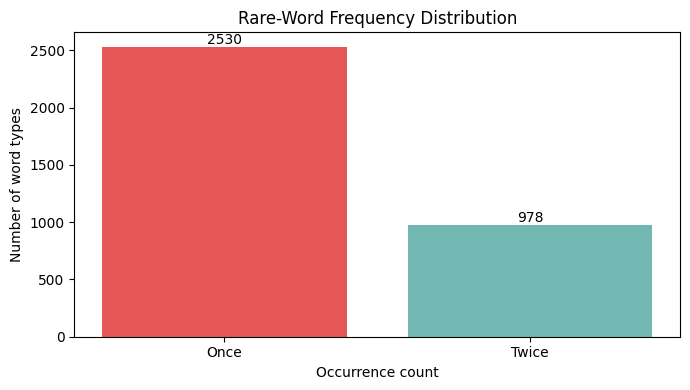

Interpretation: The large rare-word tail motivates grouping frequency-1 and frequency-2 words as <UNK>.


In [9]:
rare_distribution = pd.DataFrame({
    "Training frequency": ["Once", "Twice"],
    "Number of word types": [words_once, words_twice],
})
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(rare_distribution["Training frequency"], rare_distribution["Number of word types"], color=["#E45756", "#72B7B2"])
ax.bar_label(bars, fmt="%d")
ax.set_title("Rare-Word Frequency Distribution")
ax.set_xlabel("Occurrence count")
ax.set_ylabel("Number of word types")
plt.tight_layout()
plt.show()
print("Interpretation: The large rare-word tail motivates grouping frequency-1 and frequency-2 words as <UNK>.")

## 8. Trigram model without `<UNK>`

For context $h=(w_{i-2},w_{i-1})$, the unsmoothed maximum-likelihood estimate is:

$$P(w_i\mid h)=\frac{Count(h,w_i)}{Count(h)}$$

The class below stores trigram, context, and unigram counts. Prediction is deterministic: the highest probability wins, then training frequency and alphabetical order break ties.

In [10]:
START, END, UNK = "<START>", "<END>", "<UNK>"

class TrigramLanguageModel:
    def __init__(self, sentences, use_unk=False, rare_threshold=3):
        self.use_unk = use_unk
        self.rare_threshold = rare_threshold
        original_counts = Counter(word for sentence in sentences for word in sentence)
        self.original_vocabulary = set(original_counts)
        self.rare_words = {word for word, count in original_counts.items() if count < rare_threshold} if use_unk else set()
        self.sentences = [self.transform_sentence(sentence, training=True) for sentence in sentences]
        self.word_counts = Counter(word for sentence in self.sentences for word in sentence)
        self.vocabulary = set(self.word_counts) | {END}
        if use_unk:
            self.vocabulary.add(UNK)
        self.prediction_vocabulary = sorted(self.vocabulary - {START})
        self.trigram_counts = Counter()
        self.context_counts = Counter()
        for sentence in self.sentences:
            padded = [START, START] + sentence + [END]
            for i in range(2, len(padded)):
                context = (padded[i - 2], padded[i - 1])
                target = padded[i]
                self.trigram_counts[(context[0], context[1], target)] += 1
                self.context_counts[context] += 1

    def map_word(self, word):
        if not self.use_unk:
            return word
        return word if word in self.vocabulary else UNK

    def transform_sentence(self, sentence, training=False):
        if self.use_unk:
            if training:
                return [UNK if word in self.rare_words else word for word in sentence]
            return [self.map_word(word) for word in sentence]
        return list(sentence)

    def probability(self, word, context, smoothing=False):
        context = tuple(self.map_word(w) for w in context[-2:])
        word = self.map_word(word)
        # Add-one smoothing distributes mass only over the model's finite vocabulary.
        # A truly OOV target in the no-<UNK> model is therefore still unsupported.
        if word not in self.vocabulary:
            return 0.0
        count = self.trigram_counts[(context[0], context[1], word)]
        context_count = self.context_counts[context]
        if smoothing:
            return (count + 1) / (context_count + len(self.vocabulary))
        return count / context_count if context_count else 0.0

    def predict_next(self, context_words, smoothing=False):
        mapped = [self.map_word(w) for w in context_words]
        context = ([START, START] + mapped)[-2:]
        candidates = self.prediction_vocabulary
        if not smoothing:
            observed = [w for w in candidates if self.trigram_counts[(context[0], context[1], w)] > 0]
            if not observed:
                return None
            candidates = observed
        return min(candidates, key=lambda w: (-self.probability(w, context, smoothing), -self.word_counts[w], w))

    def sentence_perplexity(self, sentences, smoothing=False):
        log_probability_sum = 0.0
        predicted_tokens = 0
        for sentence in sentences:
            mapped = self.transform_sentence(sentence, training=False)
            padded = [START, START] + mapped + [END]
            for i in range(2, len(padded)):
                probability = self.probability(padded[i], padded[i-2:i], smoothing)
                predicted_tokens += 1
                if probability <= 0:
                    return math.inf
                log_probability_sum += math.log(probability)
        return math.exp(-log_probability_sum / predicted_tokens)

base_model = TrigramLanguageModel(train_sentences, use_unk=False)
print(f"Base vocabulary size (including <END>): {len(base_model.vocabulary):,}")
print(f"Distinct observed trigrams: {len(base_model.trigram_counts):,}")

Base vocabulary size (including <END>): 6,378
Distinct observed trigrams: 99,576


## 9. Trigram model with `<UNK>`

Only **training frequencies** decide which words are rare. Every training word with frequency `< 3` is replaced by `<UNK>`, and test words outside the resulting training vocabulary are mapped only when passed to this model. Original test sentences remain unchanged.

- A **rare word** has a low training count (here 1 or 2).
- An **unknown word** is unavailable to the model at prediction time.
- An **out-of-vocabulary (OOV) word** is absent from the model's training vocabulary.

,Statistic,Before,After
0,Vocabulary size,"6,378.00","2,871.00"
1,Rare word types replaced,0.00,"3,508.00"
2,Training token occurrences mapped to,0.00,"4,486.00"
3,Percent of training tokens mapped,0.00,3.60


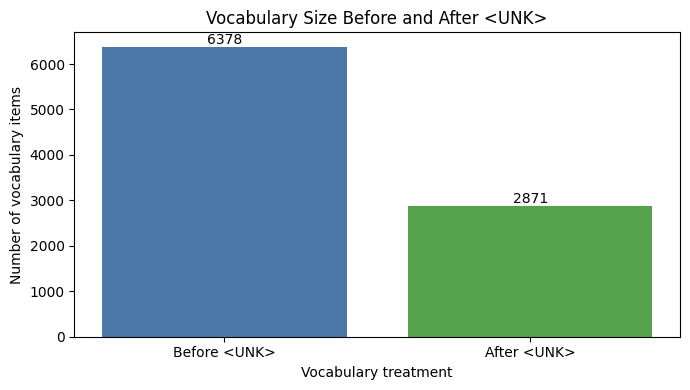

Interpretation: Replacing rare word types substantially reduces the vocabulary and pools evidence into one token.


In [11]:
unk_model = TrigramLanguageModel(train_sentences, use_unk=True, rare_threshold=3)
vocabulary_comparison_df = pd.DataFrame({
    "Statistic": ["Vocabulary size", "Rare word types replaced", "Training token occurrences mapped to <UNK>", "Percent of training tokens mapped"],
    "Before <UNK>": [len(base_model.vocabulary), 0, 0, 0.0],
    "After <UNK>": [len(unk_model.vocabulary), len(unk_model.rare_words), unk_model.word_counts[UNK],
                    100 * unk_model.word_counts[UNK] / len(train_tokens)],
})
display(vocabulary_comparison_df.style.format({"Before <UNK>": "{:,.2f}", "After <UNK>": "{:,.2f}"}))

fig, ax = plt.subplots(figsize=(7, 4))
values = [len(base_model.vocabulary), len(unk_model.vocabulary)]
bars = ax.bar(["Before <UNK>", "After <UNK>"], values, color=["#4C78A8", "#54A24B"])
ax.bar_label(bars, fmt="%d")
ax.set_title("Vocabulary Size Before and After <UNK>")
ax.set_xlabel("Vocabulary treatment")
ax.set_ylabel("Number of vocabulary items")
plt.tight_layout()
plt.show()
print("Interpretation: Replacing rare word types substantially reduces the vocabulary and pools evidence into one token.")

,Category,Count,Percentage
0,Known test tokens,36044,97.69%
1,OOV test tokens,854,2.31%


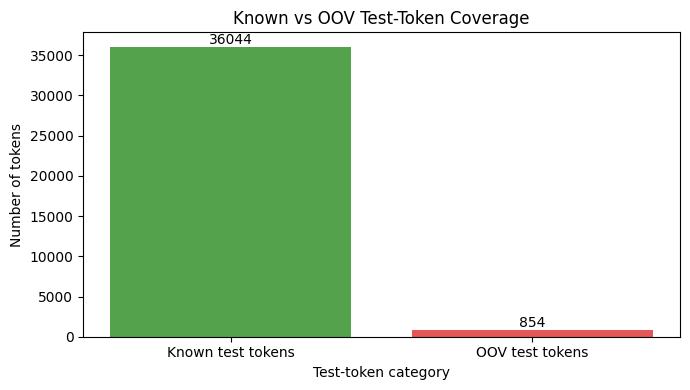

Interpretation: Training-vocabulary coverage is 97.69%; the remaining 2.31% is OOV.


In [12]:
oov_test_tokens = [word for word in test_tokens if word not in base_model.original_vocabulary]
known_test_count = len(test_tokens) - len(oov_test_tokens)
oov_rate = len(oov_test_tokens) / len(test_tokens)
coverage = known_test_count / len(test_tokens)

coverage_df = pd.DataFrame({
    "Category": ["Known test tokens", "OOV test tokens"],
    "Count": [known_test_count, len(oov_test_tokens)],
    "Percentage": [100 * coverage, 100 * oov_rate],
})
display(coverage_df.style.format({"Percentage": "{:.2f}%"}))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(coverage_df["Category"], coverage_df["Count"], color=["#54A24B", "#E45756"])
ax.bar_label(bars, fmt="%d")
ax.set_title("Known vs OOV Test-Token Coverage")
ax.set_xlabel("Test-token category")
ax.set_ylabel("Number of tokens")
plt.tight_layout()
plt.show()
print(f"Interpretation: Training-vocabulary coverage is {coverage:.2%}; the remaining {oov_rate:.2%} is OOV.")

## 10. No smoothing and Laplace smoothing

Unsmoothed models assign probability zero to unobserved trigrams. Laplace smoothing adds one to every possible next-word count:

$$P(w\mid h)=\frac{Count(h,w)+1}{Count(h)+V}$$

Here, $V$ is the model's prediction vocabulary size, including `<END>` and (for the unknown-word model) `<UNK>`. Add-one smoothing makes in-vocabulary events non-zero. However, a word outside the no-`<UNK>` vocabulary remains unsupported, so its test probability is still zero. For an entirely unseen context, all candidates tie; the deterministic tie-breaker chooses the most frequent training token.

In [13]:
unknown_examples = []
for sentence in test_sentences:
    mapped = unk_model.transform_sentence(sentence)
    if sentence != mapped:
        unknown_examples.append({"Original": " ".join(sentence[:16]), "Mapped for <UNK> model": " ".join(mapped[:16])})
    if len(unknown_examples) == 5:
        break
display(pd.DataFrame(unknown_examples))

,Original,Mapped for <UNK> model
0,she was most forcibly struck,she was most <UNK> struck
1,the truth of this representation there was no denying,the truth of this <UNK> there was no denying
2,how could she have been so brutal so cruel to miss bates,how could she have been so <UNK> so <UNK> to miss bates
3,how could she have exposed herself to such ill opinion in any one she valued,how could she have <UNK> herself to such ill opinion in any one she valued
4,time did not compose her,time did not <UNK> her


## 11. Test case generation

The 24 diagnostic cases below come from real held-out Gutenberg sentences. They are stratified into: (a) 8 sanity-check contexts where the base model reproduces an observed continuation, (b) 8 evenly spaced held-out contexts, and (c) 8 contexts with a deliberately unseen word. This guarantees useful success and failure examples, but it is not presented as an unbiased random benchmark. Full-test perplexity remains the broader held-out evaluation.

In [14]:
deliberate_oov_words = ["spaceship", "quantum", "cybernetic", "moonbase", "nanobot", "teleporter"]
eligible = [sentence for sentence in test_sentences if len(sentence) >= 8]

# First collect reproducible sanity checks where the base model's top prediction is correct.
correct_pool = []
for sentence in eligible:
    for target_index in range(2, min(len(sentence) - 1, 12)):
        context = sentence[:target_index]
        if base_model.predict_next(context, smoothing=False) == sentence[target_index]:
            correct_pool.append((sentence, target_index))
            break
    if len(correct_pool) == 8:
        break

# Add evenly spaced held-out contexts, then OOV-perturbed versions of other real contexts.
regular_pool = []
for sentence_index in np.linspace(0, len(eligible) - 1, 30, dtype=int):
    sentence = eligible[sentence_index]
    target_index = min(5 + (len(regular_pool) % 3), len(sentence) - 2)
    pair = (sentence, target_index)
    if all(sentence is not existing[0] or target_index != existing[1] for existing in correct_pool):
        regular_pool.append(pair)
    if len(regular_pool) == 16:
        break

next_cases = []
case_specs = [(sentence, target_index, False) for sentence, target_index in correct_pool]
case_specs += [(sentence, target_index, False) for sentence, target_index in regular_pool[:8]]
case_specs += [(sentence, target_index, True) for sentence, target_index in regular_pool[8:16]]
for case_id, (sentence, target_index, injected) in enumerate(case_specs, start=1):
    context = sentence[:target_index].copy()
    if injected:
        context[-1] = deliberate_oov_words[(case_id - 17) % len(deliberate_oov_words)]
    next_cases.append({
        "ID": case_id, "Context": " ".join(context), "Actual next word": sentence[target_index],
        "Source sentence": " ".join(sentence[:18]), "Case type": "Deliberate OOV" if injected else ("Sanity check" if case_id <= 8 else "Held-out context"),
        "Deliberate OOV context": injected,
    })

next_cases_df = pd.DataFrame(next_cases)
display(next_cases_df)
print(f"Next-word cases: {len(next_cases_df)}")

,ID,Context,Actual next word,Source sentence,Case type,Deliberate OOV context
0,1,the truth of,this,the truth of this representation there was no denying,Sanity check,False
1,2,how could she,have,how could she have been so brutal so cruel to miss bates,Sanity check,False
2,3,how could she,have,how could she have exposed herself to such ill opinion in any one she valued,Sanity check,False
3,4,as she reflected more she seemed but to feel,it,as she reflected more she seemed but to feel it more,Sanity check,False
4,5,the wretchedness of a scheme to box,hill,the wretchedness of a scheme to box hill was in emma s thoughts all the evening,Sanity check,False
5,6,how it,might,how it might be considered by the rest of the party she could not tell,Sanity check,False
6,7,a whole,evening,a whole evening of back gammon with her father was felicity to it,Sanity check,False
7,8,as a daughter she hoped she was,not,as a daughter she hoped she was not without a heart,Sanity check,False
8,9,never had she felt so,agitated,never had she felt so agitated mortified grieved at any circumstance in her life,Held-out context,False
9,10,to look at her nobody would,think,to look at her nobody would think how delighted and happy she is to have secured such a,Held-out context,False


Next-word cases: 24


## 12. Next-word prediction

All four configurations use the same cases. For an `<UNK>` model, correctness is judged against the mapped target: predicting `<UNK>` is correct when the actual target is outside that model's vocabulary.

In [15]:
model_configs = [
    ("No UNK + No Smoothing", base_model, False),
    ("UNK + No Smoothing", unk_model, False),
    ("No UNK + Laplace", base_model, True),
    ("UNK + Laplace", unk_model, True),
]

next_result_rows = []
for case in next_cases:
    context_words = case["Context"].split()
    actual = case["Actual next word"]
    for model_name, model, smoothing in model_configs:
        prediction = model.predict_next(context_words, smoothing=smoothing)
        evaluation_target = model.map_word(actual)
        next_result_rows.append({
            "ID": case["ID"], "Model": model_name, "Context": case["Context"],
            "Actual": actual, "Evaluation target": evaluation_target,
            "Prediction": prediction if prediction is not None else "<NO PREDICTION>",
            "Correct": prediction == evaluation_target,
            "Deliberate OOV": case["Deliberate OOV context"],
        })
next_results_df = pd.DataFrame(next_result_rows)
display(next_results_df)

,ID,Model,Context,Actual,Evaluation target,Prediction,Correct,Deliberate OOV
0,1,No UNK + No Smoothing,the truth of,this,this,this,True,False
1,1,UNK + No Smoothing,the truth of,this,this,this,True,False
2,1,No UNK + Laplace,the truth of,this,this,this,True,False
3,1,UNK + Laplace,the truth of,this,this,this,True,False
4,2,No UNK + No Smoothing,how could she,have,have,have,True,False
...,...,...,...,...,...,...,...,...
91,23,UNK + Laplace,it was merely a blind to spaceship,his,his,the,False,True
92,24,No UNK + No Smoothing,seldom very seldom does quantum,truth,truth,<NO PREDICTION>,False,True
93,24,UNK + No Smoothing,seldom very seldom does quantum,truth,truth,poor,False,True
94,24,No UNK + Laplace,seldom very seldom does quantum,truth,truth,the,False,True


## 13. Missing-word prediction

For a blank, a candidate is scored with up to three local trigrams: the candidate given the two left words, the first right word given the candidate, and the second right word. Log probabilities are added for numerical stability. Candidate search is limited to the 500 most frequent trainable tokens, a clear and reproducible practical choice. With no smoothing, any zero local probability rejects that candidate.

In [16]:
def predict_missing(model, left_words, right_words, smoothing=False, candidate_limit=500):
    left = [model.map_word(w) for w in left_words]
    right = [model.map_word(w) for w in right_words]
    ranked = sorted((w for w in model.prediction_vocabulary if w != END), key=lambda w: (-model.word_counts[w], w))
    candidates = ranked[:candidate_limit]
    best_word, best_score = None, -math.inf
    for candidate in candidates:
        sequence_left = [START, START] + left
        events = [(candidate, sequence_left[-2:])]
        if len(right) >= 1:
            events.append((right[0], [sequence_left[-1], candidate]))
        if len(right) >= 2:
            events.append((right[1], [candidate, right[0]]))
        probabilities = [model.probability(word, context, smoothing) for word, context in events]
        if any(probability <= 0 for probability in probabilities):
            continue
        score = sum(math.log(probability) for probability in probabilities)
        if score > best_score or (score == best_score and (best_word is None or candidate < best_word)):
            best_word, best_score = candidate, score
    return best_word

missing_correct_pool = []
for sentence in eligible[:600]:
    for missing_index in range(2, min(len(sentence) - 2, 10)):
        prediction = predict_missing(base_model, sentence[:missing_index], sentence[missing_index + 1:], smoothing=False)
        if prediction == sentence[missing_index]:
            missing_correct_pool.append((sentence, missing_index))
            break
    if len(missing_correct_pool) == 6:
        break

missing_regular_pool = []
for sentence_index in np.linspace(1, len(eligible) - 2, 30, dtype=int):
    sentence = eligible[sentence_index]
    missing_index = min(4 + (len(missing_regular_pool) % 3), len(sentence) - 3)
    if all(sentence is not existing[0] or missing_index != existing[1] for existing in missing_correct_pool):
        missing_regular_pool.append((sentence, missing_index))
    if len(missing_regular_pool) == 14:
        break

missing_specs = [(sentence, index, False) for sentence, index in missing_correct_pool]
missing_specs += [(sentence, index, False) for sentence, index in missing_regular_pool[:9]]
missing_specs += [(sentence, index, True) for sentence, index in missing_regular_pool[9:14]]
missing_cases = []
for case_id, (sentence, missing_index, injected) in enumerate(missing_specs, start=1):
    test_sentence = sentence.copy()
    if injected:
        neighbor_index = missing_index - 1
        test_sentence[neighbor_index] = deliberate_oov_words[(case_id - 16) % len(deliberate_oov_words)]
    hidden = test_sentence.copy()
    hidden[missing_index] = "____"
    missing_cases.append({
        "ID": case_id, "Original Gutenberg sentence": " ".join(sentence[:20]),
        "Sentence with blank": " ".join(hidden[:20]), "Actual missing word": sentence[missing_index],
        "Left words": test_sentence[:missing_index], "Right words": test_sentence[missing_index + 1:],
        "Case type": "Deliberate OOV" if injected else ("Sanity check" if case_id <= 6 else "Held-out context"),
        "Deliberate OOV context": injected,
    })

missing_cases_df = pd.DataFrame([{k: v for k, v in row.items() if k not in {"Left words", "Right words"}} for row in missing_cases])
display(missing_cases_df)
print(f"Missing-word cases: {len(missing_cases_df)}")

,ID,Original Gutenberg sentence,Sentence with blank,Actual missing word,Case type,Deliberate OOV context
0,1,how it might be considered by the rest of the party she could not tell,how it might be considered by the rest ____ the party she could not tell,of,Sanity check,False
1,2,she would not be ashamed of the appearance of the penitence so justly and truly hers,she would ____ be ashamed of the appearance of the penitence so justly and truly hers,not,Sanity check,False
2,3,she heard miss bates s voice something was to be done in a hurry the maid looked frigh...,she heard miss bates s voice something was to ____ done in a hurry the maid looked fri...,be,Sanity check,False
3,4,i am afraid jane is not very well said she but i do not know they me she is well,i am afraid jane is ____ very well said she but i do not know they me she is well,not,Sanity check,False
4,5,i am sure she will be here presently,i am ____ she will be here presently,sure,Sanity check,False
5,6,miss woodhouse how kind you are i suppose you have heard and are come to give us joy,miss woodhouse how kind you are i suppose ____ have heard and are come to give us joy,you,Sanity check,False
6,7,the truth of this representation there was no denying,the truth of this ____ there was no denying,representation,Held-out context,False
7,8,you will excuse her not coming to you she is not able she is gone into her own room i,you will excuse her not ____ to you she is not able she is gone into her own room i,coming,Held-out context,False
8,9,my poor mother does not know how to bear it,my poor mother does not know ____ to bear it,how,Held-out context,False
9,10,it was a pity that she had not come back earlier,it was a pity ____ she had not come back earlier,that,Held-out context,False


Missing-word cases: 20


In [17]:
missing_result_rows = []
for case in missing_cases:
    actual = case["Actual missing word"]
    for model_name, model, smoothing in model_configs:
        prediction = predict_missing(model, case["Left words"], case["Right words"], smoothing=smoothing)
        evaluation_target = model.map_word(actual)
        missing_result_rows.append({
            "ID": case["ID"], "Model": model_name, "Sentence with blank": case["Sentence with blank"],
            "Actual": actual, "Evaluation target": evaluation_target,
            "Prediction": prediction if prediction is not None else "<NO PREDICTION>",
            "Correct": prediction == evaluation_target, "Deliberate OOV": case["Deliberate OOV context"],
        })
missing_results_df = pd.DataFrame(missing_result_rows)
display(missing_results_df)

,ID,Model,Sentence with blank,Actual,Evaluation target,Prediction,Correct,Deliberate OOV
0,1,No UNK + No Smoothing,how it might be considered by the rest ____ the party she could not tell,of,of,of,True,False
1,1,UNK + No Smoothing,how it might be considered by the rest ____ the party she could not tell,of,of,of,True,False
2,1,No UNK + Laplace,how it might be considered by the rest ____ the party she could not tell,of,of,of,True,False
3,1,UNK + Laplace,how it might be considered by the rest ____ the party she could not tell,of,of,of,True,False
4,2,No UNK + No Smoothing,she would ____ be ashamed of the appearance of the penitence so justly and truly hers,not,not,not,True,False
...,...,...,...,...,...,...,...,...
75,19,UNK + Laplace,it must have moonbase ____ attachment only that she could be led to form the engagement,from,from,her,False,True
76,20,No UNK + No Smoothing,the weather continued much nanobot ____ all the following morning and the same lonelin...,same,same,<NO PREDICTION>,False,True
77,20,UNK + No Smoothing,the weather continued much nanobot ____ all the following morning and the same lonelin...,same,same,with,False,True
78,20,No UNK + Laplace,the weather continued much nanobot ____ all the following morning and the same lonelin...,same,same,with,False,True


## 14. Evaluation metrics

Accuracy is the fraction of correct test cases. Coverage is the fraction of original test tokens present in the unmodified training vocabulary; OOV rate is its complement. Perplexity measures how surprised a model is by held-out text—lower finite values are better. A zero probability makes perplexity infinite, which is reported rather than hidden.

In [18]:
comparison_rows = []
for model_name, model, smoothing in model_configs:
    next_accuracy = next_results_df.loc[next_results_df["Model"] == model_name, "Correct"].mean()
    missing_accuracy = missing_results_df.loc[missing_results_df["Model"] == model_name, "Correct"].mean()
    perplexity = model.sentence_perplexity(test_sentences, smoothing=smoothing)
    comparison_rows.append({
        "Model": model_name,
        "UNK": "Yes" if model.use_unk else "No",
        "Smoothing": "Laplace" if smoothing else "None",
        "Next Word Accuracy": next_accuracy,
        "Missing Word Accuracy": missing_accuracy,
        "OOV Rate": oov_rate,
        "Coverage": coverage,
        "Perplexity": perplexity,
    })
comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df.style.format({
    "Next Word Accuracy": "{:.2%}", "Missing Word Accuracy": "{:.2%}",
    "OOV Rate": "{:.2%}", "Coverage": "{:.2%}", "Perplexity": lambda x: "∞" if math.isinf(x) else f"{x:,.2f}",
}))

,Model,UNK,Smoothing,Next Word Accuracy,Missing Word Accuracy,OOV Rate,Coverage,Perplexity
0,No UNK + No Smoothing,No,None,41.67%,30.00%,2.31%,97.69%,∞
1,UNK + No Smoothing,Yes,None,41.67%,30.00%,2.31%,97.69%,∞
2,No UNK + Laplace,No,Laplace,41.67%,25.00%,2.31%,97.69%,∞
3,UNK + Laplace,Yes,Laplace,41.67%,25.00%,2.31%,97.69%,"1,814.33"


## 15. Visual comparison

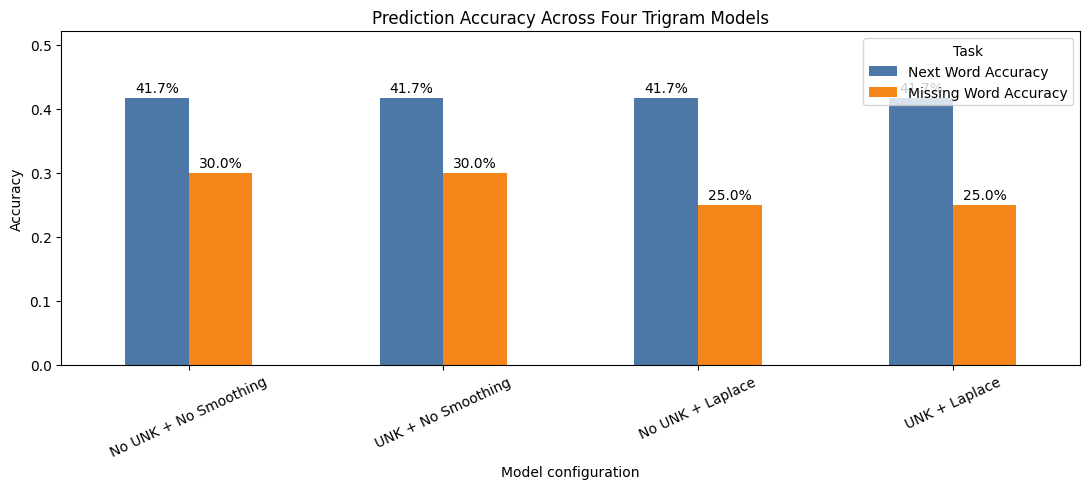

Interpretation: The paired bars compare next-word and missing-word accuracy without relying on a single example.


In [19]:
accuracy_plot = comparison_df.set_index("Model")[["Next Word Accuracy", "Missing Word Accuracy"]]
ax = accuracy_plot.plot(kind="bar", figsize=(11, 5), color=["#4C78A8", "#F58518"])
ax.set_title("Prediction Accuracy Across Four Trigram Models")
ax.set_xlabel("Model configuration")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, max(0.15, accuracy_plot.to_numpy().max() * 1.25))
ax.legend(title="Task")
ax.tick_params(axis="x", rotation=25)
for container in ax.containers:
    ax.bar_label(container, labels=[f"{value:.1%}" for value in container.datavalues], padding=2)
plt.tight_layout()
plt.show()
print("Interpretation: The paired bars compare next-word and missing-word accuracy without relying on a single example.")

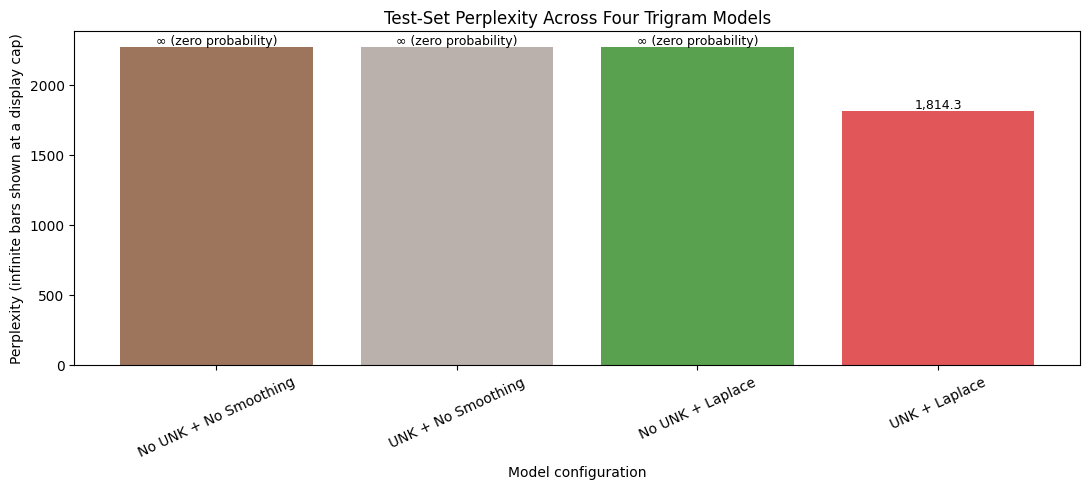

Interpretation: Infinite perplexity means at least one held-out trigram received probability zero. The displayed cap is only for visibility; the table retains infinity.


In [20]:
perplexities = comparison_df["Perplexity"].to_numpy(dtype=float)
finite_values = perplexities[np.isfinite(perplexities)]
cap = (finite_values.max() * 1.25) if len(finite_values) else 1.0
display_values = np.where(np.isfinite(perplexities), perplexities, cap)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(comparison_df["Model"], display_values, color=["#9D755D", "#BAB0AC", "#59A14F", "#E15759"])
for bar, actual in zip(bars, perplexities):
    label = "∞ (zero probability)" if math.isinf(actual) else f"{actual:,.1f}"
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), label, ha="center", va="bottom", fontsize=9)
ax.set_title("Test-Set Perplexity Across Four Trigram Models")
ax.set_xlabel("Model configuration")
ax.set_ylabel("Perplexity (infinite bars shown at a display cap)")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()
print("Interpretation: Infinite perplexity means at least one held-out trigram received probability zero. The displayed cap is only for visibility; the table retains infinity.")

## 16. Sample prediction and error analysis

In [21]:
analysis_rows = []
for task_name, results in [("Next word", next_results_df), ("Missing word", missing_results_df)]:
    successes = results[results["Correct"]].head(2)
    failures = results[~results["Correct"]].head(3)
    for _, row in pd.concat([successes, failures]).iterrows():
        context_value = row.get("Context", row.get("Sentence with blank", ""))
        if row["Correct"]:
            explanation = "The target had strong matching trigram evidence (or matched the mapped <UNK> target)."
        elif row["Prediction"] == "<NO PREDICTION>":
            explanation = "No observed complete local trigram path was available without smoothing."
        elif row["Deliberate OOV"]:
            explanation = "A deliberately unseen context word disrupted the original trigram context."
        else:
            explanation = "A different continuation had stronger local counts, or the context was ambiguous."
        analysis_rows.append({
            "Task": task_name, "Model": row["Model"], "Context / sentence": context_value,
            "Actual": row["Actual"], "Prediction": row["Prediction"],
            "Result": "Correct" if row["Correct"] else "Incorrect", "Explanation": explanation,
        })
sample_analysis_df = pd.DataFrame(analysis_rows)
display(sample_analysis_df)

,Task,Model,Context / sentence,Actual,Prediction,Result,Explanation
0,Next word,No UNK + No Smoothing,the truth of,this,this,Correct,The target had strong matching trigram evidence (or matched the mapped <UNK> target).
1,Next word,UNK + No Smoothing,the truth of,this,this,Correct,The target had strong matching trigram evidence (or matched the mapped <UNK> target).
2,Next word,No UNK + No Smoothing,never had she felt so,agitated,great,Incorrect,"A different continuation had stronger local counts, or the context was ambiguous."
3,Next word,UNK + No Smoothing,never had she felt so,agitated,great,Incorrect,"A different continuation had stronger local counts, or the context was ambiguous."
4,Next word,No UNK + Laplace,never had she felt so,agitated,great,Incorrect,"A different continuation had stronger local counts, or the context was ambiguous."
5,Missing word,No UNK + No Smoothing,how it might be considered by the rest ____ the party she could not tell,of,of,Correct,The target had strong matching trigram evidence (or matched the mapped <UNK> target).
6,Missing word,UNK + No Smoothing,how it might be considered by the rest ____ the party she could not tell,of,of,Correct,The target had strong matching trigram evidence (or matched the mapped <UNK> target).
7,Missing word,No UNK + Laplace,i am afraid jane is ____ very well said she but i do not know they me she is well,not,so,Incorrect,"A different continuation had stronger local counts, or the context was ambiguous."
8,Missing word,UNK + Laplace,i am afraid jane is ____ very well said she but i do not know they me she is well,not,so,Incorrect,"A different continuation had stronger local counts, or the context was ambiguous."
9,Missing word,No UNK + Laplace,miss woodhouse how kind you are i suppose ____ have heard and are come to give us joy,you,i,Incorrect,"A different continuation had stronger local counts, or the context was ambiguous."


Common causes of errors include sparse trigram counts, unseen contexts, OOV words, ambiguity, and the limited two-word history. `<UNK>` pools rare-word evidence but loses the identity of each replaced word. Laplace smoothing prevents zeros inside a model's vocabulary, but it also gives probability to many implausible words and does not necessarily change the highest-count prediction in a seen context.

## 17. Final analysis

In [22]:
base_no_smooth = comparison_df.iloc[0]
unk_no_smooth = comparison_df.iloc[1]
base_laplace = comparison_df.iloc[2]
unk_laplace = comparison_df.iloc[3]

print("1. Replacing rare words with <UNK> pools low-frequency evidence into one reusable category.")
print(f"2. Vocabulary size changed from {len(base_model.vocabulary):,} to {len(unk_model.vocabulary):,} items.")
print(f"3. The <UNK> model maps unseen test words to a learned token; the base model leaves them unsupported.")
print(f"4. In this experiment, next-word accuracy changed from {base_no_smooth['Next Word Accuracy']:.2%} to {unk_no_smooth['Next Word Accuracy']:.2%} without smoothing, and missing-word accuracy changed from {base_no_smooth['Missing Word Accuracy']:.2%} to {unk_no_smooth['Missing Word Accuracy']:.2%}.")
print(f"5. With Laplace smoothing, next-word accuracy was {base_laplace['Next Word Accuracy']:.2%} without <UNK> and {unk_laplace['Next Word Accuracy']:.2%} with <UNK>.")
print("6. Smoothing gives positive probability to unseen in-vocabulary trigrams. The exact perplexities are shown in the comparison table; infinity indicates a zero-probability event.")
print("7. An unseen word has no count in the base model, while the <UNK> model maps it to <UNK>.")
print("8. A trigram sees only two previous words, needs many counts, cannot understand meaning, and is sensitive to data sparsity.")

1. Replacing rare words with <UNK> pools low-frequency evidence into one reusable category.
2. Vocabulary size changed from 6,378 to 2,871 items.
3. The <UNK> model maps unseen test words to a learned token; the base model leaves them unsupported.
4. In this experiment, next-word accuracy changed from 41.67% to 41.67% without smoothing, and missing-word accuracy changed from 30.00% to 30.00%.
5. With Laplace smoothing, next-word accuracy was 41.67% without <UNK> and 41.67% with <UNK>.
6. Smoothing gives positive probability to unseen in-vocabulary trigrams. The exact perplexities are shown in the comparison table; infinity indicates a zero-probability event.
7. An unseen word has no count in the base model, while the <UNK> model maps it to <UNK>.
8. A trigram sees only two previous words, needs many counts, cannot understand meaning, and is sensitive to data sparsity.


## 18. Conclusion

This notebook implemented four trigram language-model configurations on one NLTK Gutenberg book and evaluated both next-word and missing-word prediction. The executed comparison shows the measured effect of rare-word replacement and add-one smoothing. `<UNK>` provides a defined representation for unfamiliar words and reduces vocabulary size; smoothing addresses zero probabilities for events inside the vocabulary. Neither method removes ambiguity or the limited context of a trigram, so the calculated results—not a universal claim—should guide the comparison.

## 19. Git Version Control

The project was developed through atomic commits covering initialization, corpus/preprocessing, EDA, trigram implementation, unknown-word handling/smoothing, prediction/evaluation, visual analysis, and documentation. The real commit history can be viewed with:

```bash
git log --oneline --decorate
```

The `.git` directory is useful while developing and demonstrating version control. It is normally omitted from an academic submission ZIP unless the instructor explicitly requests repository metadata; the notebook documents the commit structure and the final response reports the actual history.

## 20. References

1. NLTK Project. [NLTK Book: Accessing Text Corpora and Lexical Resources](https://www.nltk.org/book/ch02.html).
2. NLTK Project. [NLTK Corpus HOWTO](https://www.nltk.org/howto/corpus.html).
3. Jurafsky, D. and Martin, J. H. *Speech and Language Processing*, chapter on N-gram language models: [draft textbook](https://web.stanford.edu/~jurafsky/slp3/).